#Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import the datasets

In [2]:
df = pd.read_csv('11_nyc_taxi_fare.csv')
key = pd.read_csv('_key_11_true_rate_code.csv')

In [3]:
print(df.shape)
print(key.shape)

(5120, 35)
(5120, 1)


In [4]:
assert len(df) == len(key)
df['true_rate_code'] = key['true_rate_code'].values

In [5]:
print(df['true_rate_code'].value_counts().sort_index())

print(df['rate_code'].value_counts(dropna=False))


true_rate_code
1    3913
2     532
3     368
4     176
5     131
Name: count, dtype: int64
rate_code
1                     1955
NaN                   1942
Standard Rate          525
2                      249
3                      174
4                       75
JFK Flat Fare           61
5                       58
Newark                  37
Nassau/Westchester      25
Negotiated              19
Name: count, dtype: int64


#EDA

##01 Structure



In [6]:
print(df.shape)

(5120, 36)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  5120 non-null   object 
 1   medallion_id             5120 non-null   object 
 2   driver_name              5120 non-null   object 
 3   driver_experience_years  5120 non-null   float64
 4   vendor_name              5120 non-null   object 
 5   vehicle_type             5120 non-null   object 
 6   pickup_datetime          5120 non-null   object 
 7   dropoff_datetime         5120 non-null   object 
 8   trip_duration            5059 non-null   object 
 9   pickup_latitude          5120 non-null   float64
 10  pickup_longitude         5120 non-null   float64
 11  dropoff_latitude         5120 non-null   float64
 12  dropoff_longitude        5120 non-null   float64
 13  trip_distance            5120 non-null   float64
 14  pickup_borough          

##02 Check duplicates

In [8]:
print(df.duplicated().sum())
print(df['trip_id'].duplicated().sum())

120
120


In [9]:
dupes = df[df['trip_id'].duplicated(keep=False)].sort_values('trip_id')
print('Example duplicates')
display(dupes.head(6))

Example duplicates


,trip_id,medallion_id,driver_name,driver_experience_years,vendor_name,vehicle_type,pickup_datetime,dropoff_datetime,trip_duration,pickup_latitude,...,tolls_amount,extra_surcharge,mta_tax,improvement_surcharge,congestion_surcharge,tip_amount,total_amount,trip_rating,fare_amount,true_rate_code
3789,NYC-2023-400091,6556-D57,Driver 198,5.0,CMT,Hybrid,2023-04-27 20:33:00,2023-04-27 20:47:00,14m,40.778965,...,0.00,1.0,0.5,0.3,2.5,3.88,$30.19,4.0,22.01,1
2884,NYC-2023-400091,6556-D57,Driver 198,5.0,CMT,Hybrid,2023-04-27 20:33:00,2023-04-27 20:47:00,14m,40.778965,...,0.00,1.0,0.5,0.3,2.5,3.88,$30.19,4.0,22.01,1
1610,NYC-2023-400153,2828-E82,Driver 1375,6.6,Verifone,Sedan,2023-12-14 03:10:00,2023-12-14 03:22:00,12m,40.689348,...,5.38,1.0,0.5,0.3,2.5,3.87,$27.83,5.0,14.28,1
3918,NYC-2023-400153,2828-E82,Driver 1375,6.6,Verifone,Sedan,2023-12-14 03:10:00,2023-12-14 03:22:00,12m,40.689348,...,5.38,1.0,0.5,0.3,2.5,3.87,$27.83,5.0,14.28,1
4423,NYC-2023-400181,4620-E44,Driver 1233,8.9,VTS,Sedan,2023-11-25 21:13:00,2023-11-25 21:32:00,19m,40.766558,...,0.00,1.0,0.5,0.3,2.5,6.63,$37.57,4.0,26.64,1
3706,NYC-2023-400181,4620-E44,Driver 1233,8.9,VTS,Sedan,2023-11-25 21:13:00,2023-11-25 21:32:00,19m,40.766558,...,0.00,1.0,0.5,0.3,2.5,6.63,$37.57,4.0,26.64,1


##03 Check Missing values



In [10]:
miss = pd.DataFrame({'missing count': df.isna().sum(),'%': (df.isna().mean() * 100).round(2)}).sort_values('missing count', ascending=False)

miss = miss[miss['missing count'] > 0]
display(miss)

,missing count,%
rate_code,1942,37.93
congestion_surcharge,1334,26.05
passenger_count,210,4.10
traffic_index,173,3.38
precipitation_in,135,2.64
weather_condition,121,2.36
store_and_fwd_flag,97,1.89
trip_duration,61,1.19
fare_amount,10,0.20


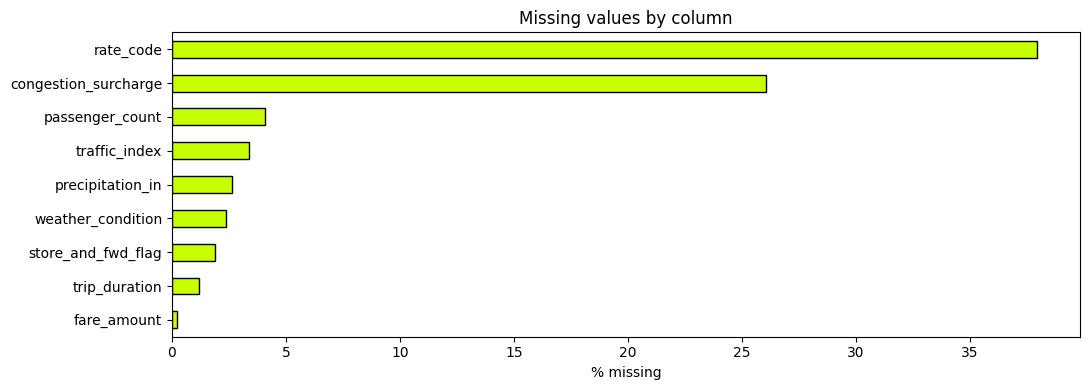

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
miss['%'].plot(kind='barh', ax=ax, color='#C8FF00', edgecolor='black')
ax.set_xlabel('% missing'); ax.set_title('Missing values by column')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

##04 Check zero Variance columns

In [12]:
nun = df.nunique(dropna=True).sort_values()
constant = nun[nun <= 1]

for c in constant.index:
    print(f'  {c:24s} -> {df[c].dropna().unique()}  (nulls: {df[c].isna().sum()})')


  mta_tax                  -> [0.5]  (nulls: 0)
  improvement_surcharge    -> [0.3]  (nulls: 0)
  congestion_surcharge     -> [2.5]  (nulls: 1334)


 #### **Conclusion 1.** `mta_tax`, `improvement_surcharge` and `congestion_surcharge`each hold one value in every populated row. Zero variance means zero contribution to any model, so all three are dropped in Part B. But `congestion_surcharge` needs investigating first - it is missing for 1,334 rows.

##05 Target analysis



In [13]:
tgt = df['fare_amount']
print(f'nulls            : {tgt.isna().sum()}')
print(f'negative         : {(tgt < 0).sum()}')
print(f'exactly zero     : {(tgt == 0).sum()}')
print(f'skewness         : {tgt.skew():.3f}')
print(f'kurtosis         : {tgt.kurtosis():.3f}')
print(tgt.describe().round(2))

nulls            : 10
negative         : 13
exactly zero     : 9
skewness         : 7.953
kurtosis         : 126.862
count    5110.00
mean       47.42
std        42.88
min       -85.09
25%        24.74
50%        37.42
75%        63.31
max       986.60
Name: fare_amount, dtype: float64


##06 Data entry error

In [14]:
ta = pd.to_numeric(df['total_amount'].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce')

# total_amount = fare + tip + tolls + all surcharges, so total must always be >= fare.

inflated = df['fare_amount'] > ta
print(f'error row count  {inflated.sum()}')

chk = pd.DataFrame({
    'fare_amount' : df.loc[inflated, 'fare_amount'],
    'fare / 10'   : df.loc[inflated, 'fare_amount'] / 10,
    'total_amount': ta[inflated],
    'tip'         : df.loc[inflated, 'tip_amount'],
    'tolls'       : df.loc[inflated, 'tolls_amount'],
})
chk['residual'] = (chk['total_amount'] - chk['fare / 10'] - chk['tip'] - chk['tolls']).round(2)
display(chk.round(2))

error row count  14


,fare_amount,fare / 10,total_amount,tip,tolls,residual
866,793.6,79.36,118.87,15.96,17.75,5.8
1181,396.7,39.67,52.77,0.00,7.30,5.8
1466,298.8,29.88,35.68,0.00,0.00,5.8
2268,834.0,83.40,103.22,16.52,0.00,3.3
2419,250.2,25.02,37.64,7.24,4.58,0.8
2775,538.6,53.86,66.68,8.52,0.00,4.3
2790,442.0,44.20,60.34,10.34,0.00,5.8
2927,986.6,98.66,117.30,0.00,16.84,1.8
2956,670.8,67.08,91.43,20.05,0.00,4.3
3136,227.9,22.79,31.07,2.48,0.00,5.8


#### **Conclusion 2.** 14 rows have a `fare_amount` inflated by exactly 10x. They are detectable because total_amount was not inflated, and total must always be at least fare. Dividing by 10 leaves a residual that is exactly the sum of the fixed surcharges, which confirms the diagnosis. These rows are **repaired, not deleted** - the trip is real, only the decimal point moved. Note that total_amount is a post trip column and is excluded from the feature set, but using it during cleaning is legitimate cleaning happens offline on historical data, not at quote time.



 #### **Conclusion 3.** The four target defects each need a different decision **10 nulls** - no label, so the row cannot train or test a model, drop. **13 negatives** - a fare cannot be negative, these are refunds or meter errors with no recoverable true value drop. **9 zeros** - no fare charged these are voided trips, not $0 rides, drop. **14 inflated** - recoverable and repaired as above, keep.Want to Total - 32 rows removed, 14 repaired.



##07 The distance column is in two units

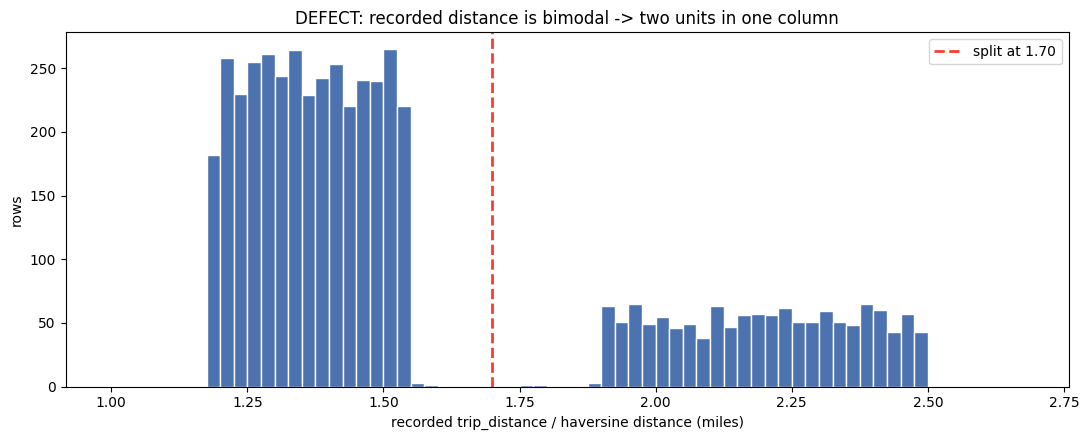

ratio < 1.7 (already miles) : 3695
ratio > 1.7 (kilometres)    : 1291
ratio of the two modes      : 1.6218


In [15]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    p = np.pi / 180
    a = (np.sin((lat2-lat1)*p/2)**2
         + np.cos(lat1*p) * np.cos(lat2*p) * np.sin((lon2-lon1)*p/2)**2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

g = df.copy()
# temporarily repair coordinates so the ratio is meaningful
for la, lo in [('pickup_latitude','pickup_longitude'), ('dropoff_latitude','dropoff_longitude')]:
    m = (g[la] < 0) & (g[lo] > 0)
    g.loc[m, [la, lo]] = g.loc[m, [lo, la]].values
for c in ['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']:
    g.loc[g[c] == 0, c] = np.nan

g['hav'] = haversine_miles(g.pickup_latitude, g.pickup_longitude,
                           g.dropoff_latitude, g.dropoff_longitude)
ratio = (g['trip_distance'] / g['hav']).replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(ratio.dropna(), bins=np.arange(1.0, 2.7, 0.025),
        color='#4C72B0', edgecolor='white')
ax.axvline(1.7, color='#FF3B30', ls='--', lw=2, label='split at 1.70')
ax.set_xlabel('recorded trip_distance / haversine distance (miles)')
ax.set_ylabel('rows')
ax.set_title('DEFECT: recorded distance is bimodal -> two units in one column')
ax.legend(); plt.tight_layout(); plt.show()

print(f'ratio < 1.7 (already miles) : {(ratio < 1.7).sum()}')
print(f'ratio > 1.7 (kilometres)    : {(ratio > 1.7).sum()}')
print(f'ratio of the two modes      : {ratio[ratio>1.7].median() / ratio[ratio<1.7].median():.4f}')

####**Conclusion 4.** The ratio of recorded distance to great-circle distance is sharply **bimodal** with an empty gap between 1.55 and 1.85. The lower mode sits at 1.15-1.55, which is the normal road-circuity factor for a city grid. The upper mode is the same distribution multiplied by **1.609** - the miles-to-km conversion factor. Roughly 1,250 rows were logged in kilometres. They are **converted, not deleted**, by multiplying by 1/1.609344.



##08 Check the coordinates


In [16]:
zero_coord = ((df[['pickup_latitude','pickup_longitude']] == 0).any(axis=1)
              | (df[['dropoff_latitude','dropoff_longitude']] == 0).any(axis=1))
swapped_p  = (df['pickup_latitude']  < 0) & (df['pickup_longitude']  > 0)
swapped_d  = (df['dropoff_latitude'] < 0) & (df['dropoff_longitude'] > 0)

print(f'(a) GPS failed, coordinate exactly 0 : {zero_coord.sum()} rows')
print(f'(b) lat/lon written into wrong field : {(swapped_p | swapped_d).sum()} rows')
print(f'(c) everything else = normal jitter  : {len(df) - zero_coord.sum() - (swapped_p|swapped_d).sum()} rows')



(a) GPS failed, coordinate exactly 0 : 134 rows
(b) lat/lon written into wrong field : 47 rows
(c) everything else = normal jitter  : 4939 rows



 #### **Conclusion 5.** New York City sits at roughly **+40.7 latitude, -74.0 longitude**. Latitude must be positive and longitude negative for any NYC point, which makes both defects trivially detectable. 47 rows have the two fields transposed and are **swapped back**. 134 rows have a coordinate of exactly zero from a GPS unit that never acquired a fix, these are set to **NaN** rather than left at zero, because a haversine distance computed from(0, 0) is not merely inaccurate, it is a distance to a point in the Atlantic Ocean and would poison every derived feature.



##09 The pickup timestamp is in two formats



In [17]:
s = df['pickup_datetime'].astype(str).str.strip()
slash = s.str.contains('/')
print(f'DD/MM/YYYY HH:MM  : {slash.sum()} rows   e.g. {s[slash].iloc[0]}')
print(f'YYYY-MM-DD HH:MM:SS: {(~slash).sum()} rows   e.g. {s[~slash].iloc[0]}')

print('\n--- what naive parsing does ---')
naive = pd.to_datetime(s, errors='coerce', format='mixed', dayfirst=False)
print(f'nulls BEFORE parsing : {df["pickup_datetime"].isna().sum()}')
print(f'nulls AFTER  naive   : {naive.isna().sum()}')

tmp = pd.DataFrame(index=df.index)
tmp.loc[slash, 'pickup_dt'] = pd.to_datetime(s[slash], format='%d/%m/%Y %H:%M', errors='coerce')
tmp.loc[~slash, 'pickup_dt'] = pd.to_datetime(s[~slash], format='%Y-%m-%d %H:%M:%S', errors='coerce')

correct = tmp['pickup_dt']
print(f'nulls AFTER  correct : {correct.isna().sum()}')

comp = pd.DataFrame({'raw': s[slash], 'naive': naive[slash], 'correct': correct[slash]}).head(6)
display(comp)

DD/MM/YYYY HH:MM  : 640 rows   e.g. 19/07/2023 19:36
YYYY-MM-DD HH:MM:SS: 4480 rows   e.g. 2023-10-31 06:21:00

--- what naive parsing does ---
nulls BEFORE parsing : 0
nulls AFTER  naive   : 0
nulls AFTER  correct : 0


,raw,naive,correct
0,19/07/2023 19:36,2023-07-19 19:36:00,2023-07-19 19:36:00
1,17/08/2023 08:26,2023-08-17 08:26:00,2023-08-17 08:26:00
40,14/10/2023 07:12,2023-10-14 07:12:00,2023-10-14 07:12:00
56,04/08/2023 00:18,2023-04-08 00:18:00,2023-08-04 00:18:00
59,29/07/2023 19:02,2023-07-29 19:02:00,2023-07-29 19:02:00
60,02/01/2023 04:48,2023-02-01 04:48:00,2023-01-02 04:48:00


#### **Conclusion 6.** The column mixes two conventions. Parsing with default settings silently reads `19/07/2023` as month 19 or flips day and month, reversing the date for 640 rows without raising an error. Each format is therefore parsed **separately with an explicit `format=` string**, and null counts are compared before and after to prove no rows were lost.



##10 Sentinel values and impossible values

In [18]:
print(f'rows with temperature_f == -999 : {(df.temperature_f == -999).sum()}')
print(f'passenger_count values: {sorted(df.passenger_count.dropna().unique())}')
print(f'  == 0 : {(df.passenger_count == 0).sum()}')
print(f'  >  6 : {(df.passenger_count > 6).sum()}')
print(f'  null : {df.passenger_count.isna().sum()}')
print(f'trip_distance == 0 but coordinates differ: '
      f'{((df.trip_distance == 0) & (g.hav > 0.1)).sum()} rows')

rows with temperature_f == -999 : 38
passenger_count values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(9.0)]
  == 0 : 67
  >  6 : 20
  null : 210
trip_distance == 0 but coordinates differ: 87 rows


#### **Conclusion 7.** `temperature_f` uses **-999** as a missing-reading sentinel. Left in place it drags the column mean far below any real temperature and destroys every correlation involving weather. It is converted to NaN and imputed. `passenger_count` contains **0** (impossible — a trip occurred) and **9** (above the 6-passenger legal maximum for a NYC taxi) both are treated as missing rather than clipped, because the true value is unknown.



##11 Categorical columns



In [19]:
for col in ['vendor_name', 'payment_type', 'weather_condition']:
    print(f' {col} ({df[col].nunique(dropna=False)} raw categories) ')
    print(df[col].value_counts(dropna=False).to_string())
    print()

 vendor_name (6 raw categories) 
vendor_name
VTS         2057
CMT         1901
Verifone     652
vts          223
cmt          212
VERIFONE      75

 payment_type (7 raw categories) 
payment_type
Credit Card    2621
Cash           1273
CRD             747
CSH             340
No Charge        76
Dispute          41
No charge        22

 weather_condition (7 raw categories) 
weather_condition
Clear    3043
Rain     1077
Fog       284
Snow      259
clear     243
NaN       121
RAIN       93



#### **Conclusion 8.** Three columns carry the same real category written several ways. `vendor_name` mixes case and trailing whitespace (`VTS` / `vts `). `payment_type` mixes abbreviations with full names (`CRD` / `Credit Card`, `CSH` / `Cash`) *and* case (`No Charge` / `No charge`). `weather_condition` mixes case (`Clear` / `clear` / `RAIN`). Encoding before normalising would create phantom levels that split the signal and inflate dimensionality. All three are stripped, case-normalised and mapped to canonical.



##12 Analysis of the key predictors



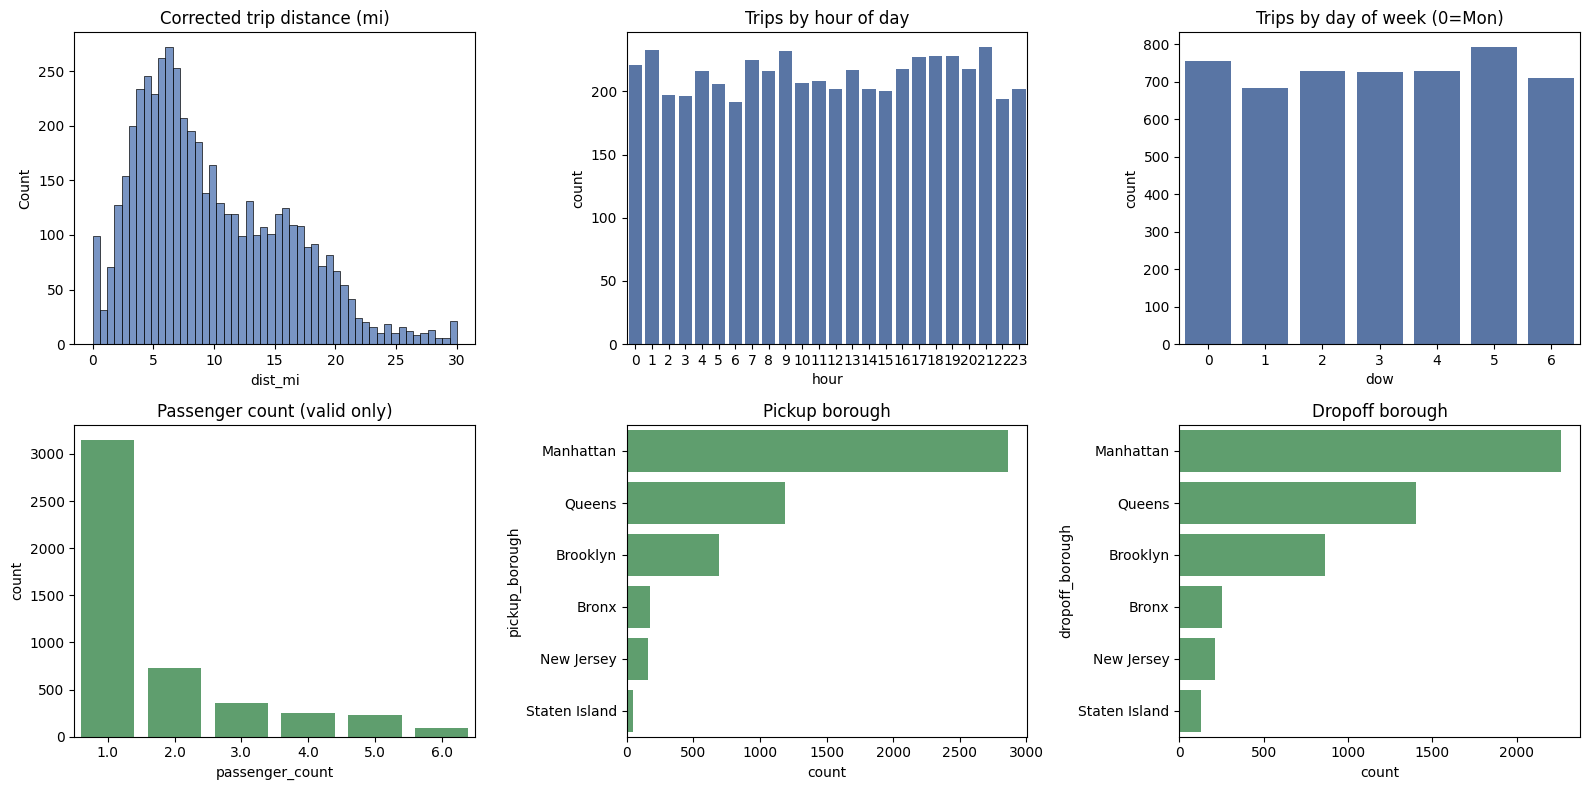

In [20]:
g['dist_mi'] = np.where(ratio > 1.7, g.trip_distance / 1.609344, g.trip_distance)
g['fare'] = np.where(g.fare_amount > ta, g.fare_amount / 10, g.fare_amount)
g['hour'] = tmp.pickup_dt.dt.hour
g['dow']  = tmp.pickup_dt.dt.dayofweek

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sns.histplot(g.dist_mi.clip(0, 30), bins=50, ax=axes[0,0], color='#4C72B0'); axes[0,0].set_title('Corrected trip distance (mi)')
sns.countplot(x=g.hour, ax=axes[0,1], color='#4C72B0');                       axes[0,1].set_title('Trips by hour of day')
sns.countplot(x=g.dow, ax=axes[0,2], color='#4C72B0');                        axes[0,2].set_title('Trips by day of week (0=Mon)')
sns.countplot(x=g.passenger_count.where(g.passenger_count.between(1,6)), ax=axes[1,0], color='#55A868'); axes[1,0].set_title('Passenger count (valid only)')
sns.countplot(y=g.pickup_borough, ax=axes[1,1], color='#55A868', order=g.pickup_borough.value_counts().index); axes[1,1].set_title('Pickup borough')
sns.countplot(y=g.dropoff_borough, ax=axes[1,2], color='#55A868', order=g.dropoff_borough.value_counts().index); axes[1,2].set_title('Dropoff borough')
plt.tight_layout(); plt.show()

##13 Bivariate analysis against the target



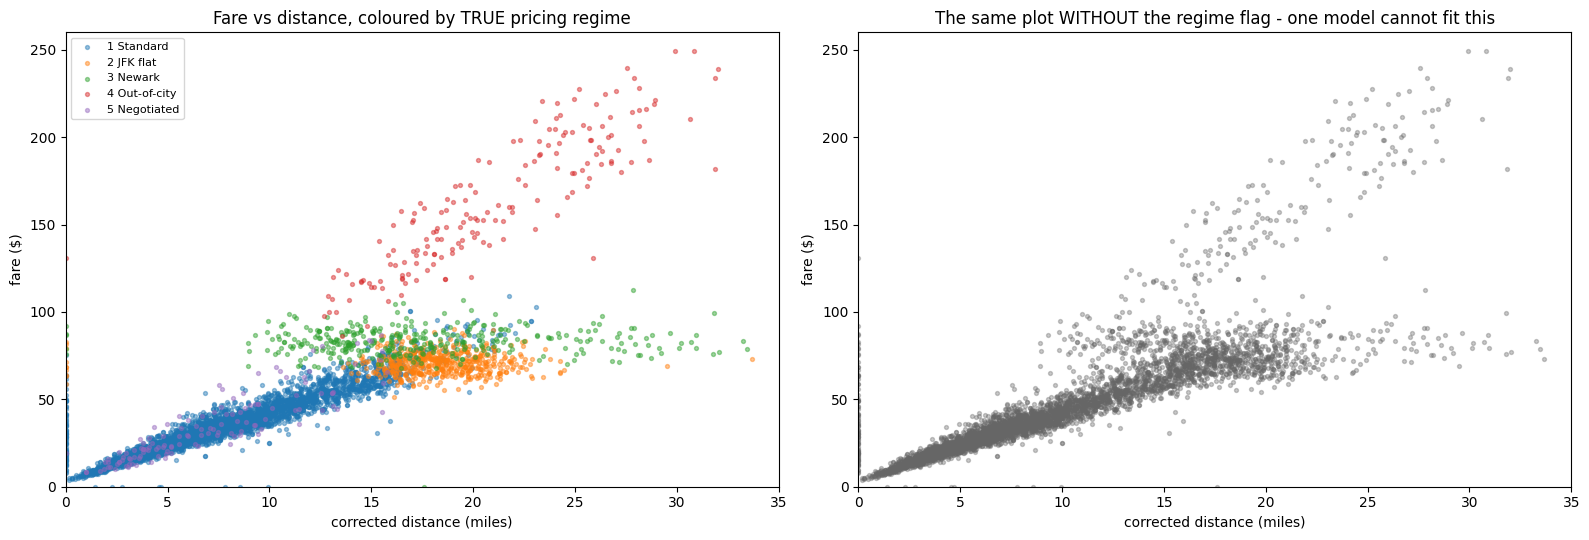

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for code, name in [(1,'1 Standard'), (2,'2 JFK flat'), (3,'3 Newark'),
                   (4,'4 Out-of-city'), (5,'5 Negotiated')]:
    sub = g[g.true_rate_code == code]
    axes[0].scatter(sub.dist_mi, sub.fare, s=8, alpha=.45, label=name)
axes[0].set_xlim(0, 35); axes[0].set_ylim(0, 260)
axes[0].set_xlabel('corrected distance (miles)'); axes[0].set_ylabel('fare ($)')
axes[0].set_title('Fare vs distance, coloured by TRUE pricing regime')
axes[0].legend(fontsize=8)

axes[1].scatter(g.dist_mi, g.fare, s=8, alpha=.35, c='#666666')
axes[1].set_xlim(0, 35); axes[1].set_ylim(0, 260)
axes[1].set_xlabel('corrected distance (miles)'); axes[1].set_ylabel('fare ($)')
axes[1].set_title('The same plot WITHOUT the regime flag - one model cannot fit this')
plt.tight_layout(); plt.show()


#### **Conclusion 9.** This is the single most important chart in the project. The left panel shows that the data contains several distinct price-distance relationships stacked on top of each other, a sloped metered line for regime 1, a horizontal band near 70 for JFK trips regardless of distance, a second horizontal band near 83 for Newark, and a steeper, much higher band for out-of-city trips. The right panel is what a model sees without the regime flag - a single cloud with no learnable structure in the flat-rate region. Fitting one model across all trips will look acceptable on average while being badly wrong on roughly a fifth of trips. Recovering this flag is therefore the highest-value feature in the project.


##14 Correlation and multicollinearity

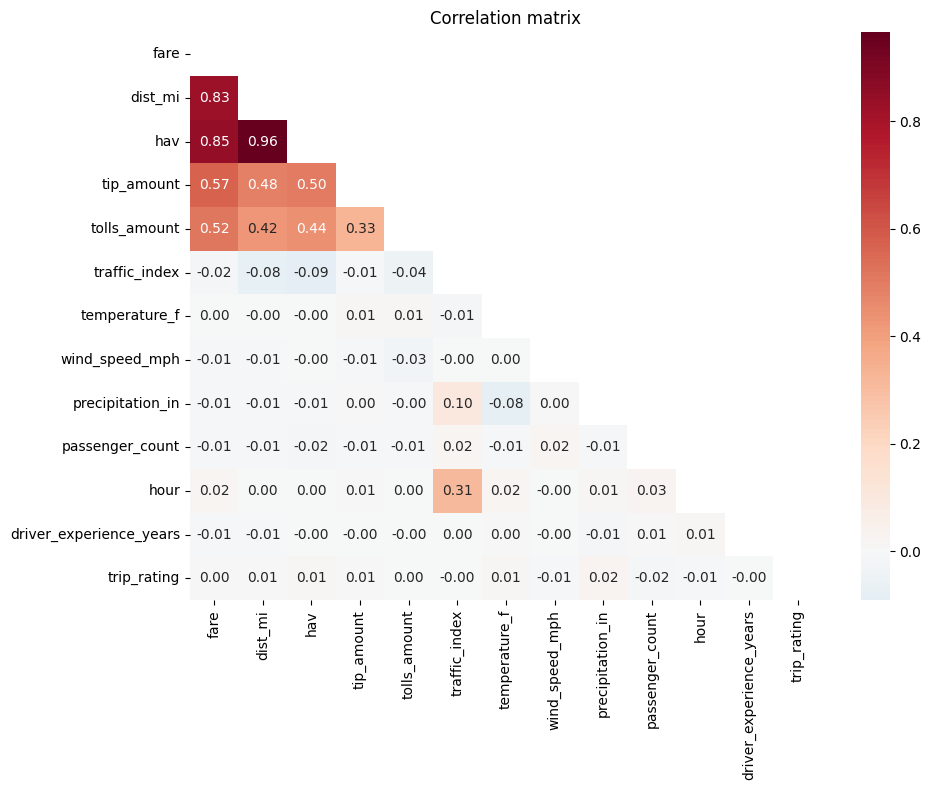

Correlation with fare, ranked -
hav                        0.848
dist_mi                    0.826
tip_amount                 0.571
tolls_amount               0.519
hour                       0.017
trip_rating                0.004
temperature_f              0.003
precipitation_in          -0.005
wind_speed_mph            -0.009
passenger_count           -0.012
driver_experience_years   -0.012
traffic_index             -0.017


In [22]:
corr_cols = ['fare','dist_mi','hav','tip_amount','tolls_amount','traffic_index',
             'temperature_f','wind_speed_mph','precipitation_in','passenger_count',
             'hour','driver_experience_years','trip_rating']
cm = g[corr_cols].replace(-999, np.nan).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            mask=np.triu(np.ones_like(cm, dtype=bool)))
ax.set_title('Correlation matrix')
plt.tight_layout(); plt.show()

print('Correlation with fare, ranked -')
print(cm['fare'].drop('fare').sort_values(ascending=False).round(3).to_string())



#### **Conclusion 10. (multicollinearity).** `dist_mi` and `hav` correlate above **0.95** - they measure the same physical quantity, one from the meter and one from the coordinates. Both cannot enter a linear model without inflating variance and destabilising coefficients. Since the meter distance is a post-trip value, the choice is made for us, **`hav` is kept, `dist_mi` is dropped**. `tip_amount` correlates 0.45 with fare but is a post-trip column and is excluded regardless. `driver_experience_years` and `trip_rating` correlate near zero with the target *and* are unavailable at quote time.



##15 Summary of findings

| # | Defect | Rows affected | Treatment in Part B |
|---|---|---:|---|
| 1 | Duplicate double logged rows | 120 | Drop after attaching the key |
| 2 | `trip_distance` in two units | ~1,250 | Detect via haversine ratio, convert km to mi |
| 3 | Coordinates exactly zero | 134 | Set to NaN, impute |
| 4 | Latitude/longitude transposed | 47 | Swap back |
| 5 | Two datetime formats | 640 / 4,480 | Parse each with an explicit format |
| 6 | `trip_duration` stored as text | all | Regex to minutes (analysis only) |
| 7 | `total_amount` stored as text | all | Strip `$` and commas |
| 8 | `temperature_f` sentinel -999 | see output | NaN then impute |
| 9 | `passenger_count` 0 and 9 | see output | NaN then impute |
| 10 | Dirty categories x3 columns | many | Strip, case-normalise, map abbreviations |
| 11 | Target null / negative / zero | 32 | Drop |
| 12 | Target inflated 10x | 14 | Divide by 10 |
| 13 | Zero-variance columns | 3 cols | Drop |
| 14 | `congestion_surcharge` structural gap | 1,334 | Fill 0, then drop column |
| 15 | `rate_code` unreliable | 1,942 null | Rebuild from geography |
| 16 | Post-trip columns | 14 cols | Excluded with written reasoning |